# Etapa 5.1 — Consolidação de Desempenho e Evidências para H1

Consolida os resultados das Etapas 2–4 em dois artefatos finais:
- Tabela comparativa R²(k=8) vs. R²(k=6) para SVR, ANN e XGBoost
- Painel unificado com as três camadas de evidência que validam H1

Nenhum modelo é carregado ou treinado — toda a computação é leitura e visualização de artefatos já produzidos.

## Seção 1 — Imports e carga de artefatos

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150

ETAPA5 = Path('.').resolve()
ARTEFATOS = ETAPA5.parent

PATH_BASELINE = ARTEFATOS / 'ETAPA_2' / 'baseline_resultados.csv'
PATH_EQUIV    = ARTEFATOS / 'ETAPA_3' / 'equivalencia' / '3.4_equivalencia_resultados.csv'
PATH_KSTAR    = ARTEFATOS / 'ETAPA_3' / 'reduzido' / '3.5_k_estrela.json'
PATH_SHAP     = ARTEFATOS / 'ETAPA_3' / 'shap' / '3.1' / '3.1_shap_consolidado.csv'
PATH_SOBOL    = ARTEFATOS / 'ETAPA_4' / '4.1_sobol_8inputs_resultados.csv'

df_baseline = pd.read_csv(PATH_BASELINE)
df_equiv    = pd.read_csv(PATH_EQUIV)
# normalizar coluna boolean (lida como string por alguns parsers)
df_equiv['equivalente'] = df_equiv['equivalente'].astype(str).str.strip().map({'True': True, 'False': False})

with open(PATH_KSTAR) as f:
    kstar = json.load(f)

df_shap  = pd.read_csv(PATH_SHAP)
df_sobol = pd.read_csv(PATH_SOBOL)

print('Artefatos carregados:')
print(f'  baseline:   {df_baseline.shape}')
print(f'  equiv:      {df_equiv.shape}')
print(f'  SHAP:       {df_shap.shape}')
print(f'  Sobol:      {df_sobol.shape}')

Artefatos carregados:
  baseline:   (15, 11)
  equiv:      (45, 10)
  SHAP:       (120, 5)
  Sobol:      (24, 6)


In [2]:
# Validação de integridade
assert df_baseline[['Modelo', 'Output', 'test_r2']].isna().sum().sum() == 0
assert df_equiv[['arquitetura', 'output', 'k', 'ic_inf', 'ic_sup', 'equivalente']].isna().sum().sum() == 0
assert df_shap[['modelo', 'output', 'feature', 'shap_mean']].isna().sum().sum() == 0
assert df_sobol[['output', 'feature', 'ST']].isna().sum().sum() == 0
assert kstar['k_estrela'] == 6, f"k* esperado=6, obtido={kstar['k_estrela']}"
assert kstar['arquitetura_recomendada'] == 'SVR'

print('Integridade: OK')
print(f"k* = {kstar['k_estrela']}")
print(f"S_k* = {kstar['S_k_estrela']}")
print(f"Arquitetura recomendada: {kstar['arquitetura_recomendada']}")

Integridade: OK
k* = 6
S_k* = ['T1', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
Arquitetura recomendada: SVR


## Seção 2 — Tabela consolidada de R² (baseline k=8 vs. reduzido k*=6)

Modelos incluídos: SVR (arquitetura recomendada), ANN e XGBoost (melhor desempenho absoluto no baseline). DT e RF omitidos por terem R² inferior e não serem recomendados (D-E5-02).

In [3]:
MODELOS  = ['SVR', 'ANN', 'XGBoost']
OUTPUTS  = ['ET', 'M_CH3OH', 'x_CH3OH']

# R² baseline (k=8)
df_base_sel = (
    df_baseline[df_baseline['Modelo'].isin(MODELOS)]
    [['Modelo', 'Output', 'test_r2']]
    .rename(columns={'Modelo': 'modelo', 'Output': 'output', 'test_r2': 'R2_k8'})
)

# R² reduzido (k=6) com flag de equivalência
df_red_sel = (
    df_equiv[(df_equiv['arquitetura'].isin(MODELOS)) & (df_equiv['k'] == 6)]
    [['arquitetura', 'output', 'r2_k', 'equivalente']]
    .rename(columns={'arquitetura': 'modelo', 'r2_k': 'R2_k6'})
)

df_r2 = df_base_sel.merge(df_red_sel, on=['modelo', 'output'])
df_r2['delta_r2'] = (df_r2['R2_k8'] - df_r2['R2_k6']).round(4)
df_r2['equivalente'] = df_r2['equivalente'].map({True: 'Sim', False: 'Não'})
df_r2['R2_k8'] = df_r2['R2_k8'].round(4)
df_r2['R2_k6'] = df_r2['R2_k6'].round(4)
df_r2 = df_r2[['modelo', 'output', 'R2_k8', 'R2_k6', 'delta_r2', 'equivalente']]

ordem_modelo = {m: i for i, m in enumerate(['SVR', 'XGBoost', 'ANN'])}
ordem_output = {o: i for i, o in enumerate(OUTPUTS)}
df_r2 = df_r2.sort_values(['modelo', 'output'],
                           key=lambda col: col.map(ordem_modelo if col.name == 'modelo' else ordem_output))
df_r2 = df_r2.reset_index(drop=True)

display(df_r2)
df_r2.to_csv(ETAPA5 / '5.1_tabela_r2_baseline_vs_reduzido.csv', index=False)
print('Salvo: 5.1_tabela_r2_baseline_vs_reduzido.csv')

,modelo,output,R2_k8,R2_k6,delta_r2,equivalente
0,SVR,ET,0.9701,0.9719,-0.0018,Sim
1,SVR,M_CH3OH,0.9831,0.9764,0.0067,Sim
2,SVR,x_CH3OH,0.9531,0.9684,-0.0153,Sim
3,XGBoost,ET,0.9634,0.9714,-0.0080,Sim
4,XGBoost,M_CH3OH,0.9602,0.9505,0.0097,Sim
5,XGBoost,x_CH3OH,0.9451,0.9354,0.0097,Não
6,ANN,ET,0.9647,0.9732,-0.0085,Sim
7,ANN,M_CH3OH,0.9846,0.9702,0.0144,Não
8,ANN,x_CH3OH,0.9689,0.9812,-0.0123,Sim


Salvo: 5.1_tabela_r2_baseline_vs_reduzido.csv


In [4]:
# Validação da tabela
assert df_r2.isna().sum().sum() == 0, 'NaN na tabela de R²'
svr_equiv = df_r2[df_r2['modelo'] == 'SVR']['equivalente']
assert (svr_equiv == 'Sim').all(), f'SVR k=6 não-equivalente em algum output: {svr_equiv.values}'
print('Validação da tabela: OK — SVR k=6 equivalente nos 3 outputs')

Validação da tabela: OK — SVR k=6 equivalente nos 3 outputs


## Seção 3 — Painel das três camadas de evidência para H1

**H1:** As features P1 (pressão do reator) e T2 (temperatura de entrada na coluna) são irrelevantes para os três outputs.

Três blocos independentes de evidência:
- **Bloco 1 — Empírica:** IC 95% de ΔR² (SVR k=8 → k=6) via bootstrap
- **Bloco 2 — Baseada em modelo (SHAP):** importância relativa máxima de P1 e T2
- **Bloco 3 — Física/agnóstica (Sobol):** índice de efeito total S_T de P1 e T2

In [5]:
# --- Bloco 1: SVR k=6 da equivalência estatística ---
svr6 = (
    df_equiv[(df_equiv['arquitetura'] == 'SVR') & (df_equiv['k'] == 6)]
    .set_index('output')
)

# --- Bloco 2: SHAP relativo (max sobre os 5 modelos) ---
df_shap_rel = df_shap.copy()
totais = df_shap_rel.groupby(['modelo', 'output'])['shap_mean'].transform('sum')
df_shap_rel['shap_rel'] = df_shap_rel['shap_mean'] / totais * 100

shap_p1t2 = (
    df_shap_rel[df_shap_rel['feature'].isin(['P1', 'T2'])]
    .groupby(['output', 'feature'])['shap_rel']
    .max()
    .unstack('feature')
    .reindex(OUTPUTS)
)

# --- Bloco 3: Sobol S_T ---
sobol_p1t2 = (
    df_sobol[df_sobol['feature'].isin(['P1', 'T2'])]
    .pivot(index='output', columns='feature', values='ST')
    .reindex(OUTPUTS)
)

print('SHAP max relativo por output:')
print(shap_p1t2.round(3))
print('\nSobol S_T por output:')
print(sobol_p1t2.round(4))

SHAP max relativo por output:
feature     P1     T2
output               
ET       1.620  0.950
M_CH3OH  2.622  0.725
x_CH3OH  2.088  1.842

Sobol S_T por output:
feature      P1      T2
output                 
ET       0.0058  0.0046
M_CH3OH  0.0133  0.0026
x_CH3OH  0.0091  0.0092


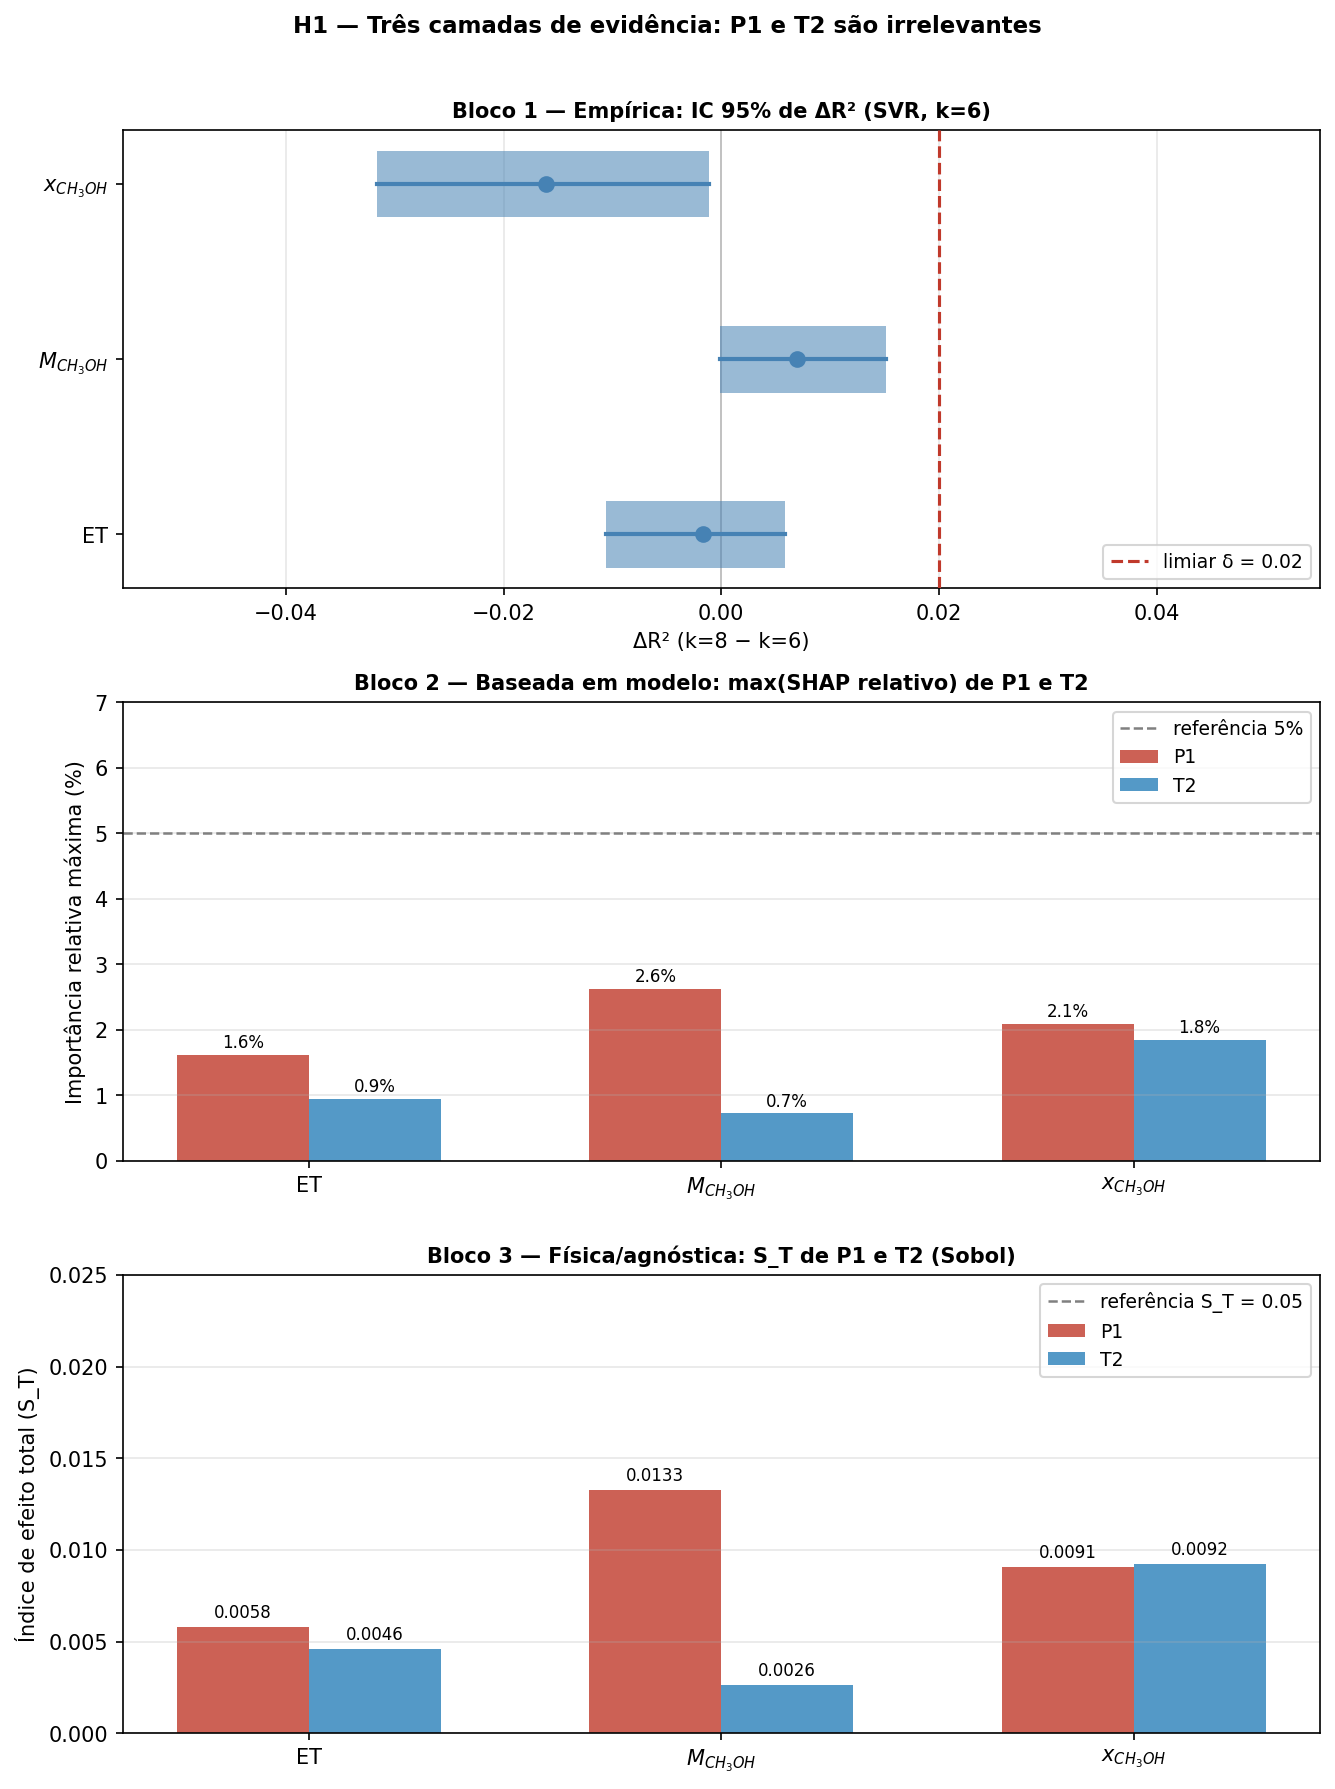

Salvo: 5.1_painel_h1_evidencias.png


In [6]:
output_labels = ['ET', '$M_{CH_3OH}$', '$x_{CH_3OH}$']
cores = {'P1': '#c0392b', 'T2': '#2980b9'}
x = np.arange(len(OUTPUTS))
w = 0.32

fig, axes = plt.subplots(3, 1, figsize=(9, 12))
fig.suptitle(
    'H1 — Três camadas de evidência: P1 e T2 são irrelevantes',
    fontsize=11, fontweight='bold', y=0.99
)

# ── Bloco 1: Forest plot (IC 95%) ──────────────────────────────────────────────
ax1 = axes[0]
y_pos = np.arange(len(OUTPUTS))

for i, out in enumerate(OUTPUTS):
    row = svr6.loc[out]
    centro = float(row['delta_r2_boot_medio'])
    ic_inf = float(row['ic_inf'])
    ic_sup = float(row['ic_sup'])
    ax1.barh(i, ic_sup - ic_inf, left=ic_inf, height=0.38,
             color='steelblue', alpha=0.55, zorder=2)
    ax1.plot(centro, i, 'o', color='steelblue', markersize=7, zorder=3)
    ax1.plot([ic_inf, ic_sup], [i, i], '-', color='steelblue', linewidth=2, zorder=3)

ax1.axvline(x=0.02, color='#c0392b', linestyle='--', linewidth=1.5,
            label='limiar δ = 0.02', zorder=4)
ax1.axvline(x=0.00, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, zorder=1)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(output_labels)
ax1.set_xlabel('ΔR² (k=8 − k=6)')
ax1.set_xlim(-0.055, 0.055)
ax1.set_title('Bloco 1 — Empírica: IC 95% de ΔR² (SVR, k=6)',
              fontweight='bold', fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# ── Bloco 2: SHAP relativo ─────────────────────────────────────────────────────
ax2 = axes[1]

for j, feat in enumerate(['P1', 'T2']):
    vals = shap_p1t2[feat].values
    bars = ax2.bar(x + j * w, vals, w, label=feat,
                   color=cores[feat], alpha=0.80)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

ax2.axhline(y=5, color='gray', linestyle='--', linewidth=1.2,
            label='referência 5%')
ax2.set_xticks(x + w / 2)
ax2.set_xticklabels(output_labels)
ax2.set_ylabel('Importância relativa máxima (%)')
ax2.set_ylim(0, max(shap_p1t2.values.max() * 1.45, 7))
ax2.set_title('Bloco 2 — Baseada em modelo: max(SHAP relativo) de P1 e T2',
              fontweight='bold', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# ── Bloco 3: Sobol S_T ────────────────────────────────────────────────────────
ax3 = axes[2]

for j, feat in enumerate(['P1', 'T2']):
    vals = sobol_p1t2[feat].values
    bars = ax3.bar(x + j * w, vals, w, label=feat,
                   color=cores[feat], alpha=0.80)
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax3.axhline(y=0.05, color='gray', linestyle='--', linewidth=1.2,
            label='referência S_T = 0.05')
ax3.set_xticks(x + w / 2)
ax3.set_xticklabels(output_labels)
ax3.set_ylabel('Índice de efeito total (S_T)')
ax3.set_ylim(0, max(sobol_p1t2.values.max() * 1.50, 0.025))
ax3.set_title('Bloco 3 — Física/agnóstica: S_T de P1 e T2 (Sobol)',
              fontweight='bold', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(ETAPA5 / '5.1_painel_h1_evidencias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: 5.1_painel_h1_evidencias.png')

In [7]:
# Validação do painel
for out in OUTPUTS:
    ic_sup = float(svr6.loc[out, 'ic_sup'])
    assert ic_sup <= 0.02, f'Bloco 1: ic_sup({out}) = {ic_sup:.4f} > 0.02'

for feat in ['P1', 'T2']:
    max_shap = shap_p1t2[feat].max()
    assert max_shap < 5.0, f'Bloco 2: max_shap_rel({feat}) = {max_shap:.2f}% >= 5%'

for feat in ['P1', 'T2']:
    max_st = sobol_p1t2[feat].max()
    assert max_st < 0.015, f'Bloco 3: max_ST({feat}) = {max_st:.4f} >= 0.015'

print('Validação do painel: OK')
print(f'  Bloco 1 — todos os ic_sup <= 0.02: OK')
print(f'  Bloco 2 — max SHAP P1 = {shap_p1t2["P1"].max():.2f}%, T2 = {shap_p1t2["T2"].max():.2f}% (ambos < 5%)')
print(f'  Bloco 3 — max S_T P1 = {sobol_p1t2["P1"].max():.4f}, T2 = {sobol_p1t2["T2"].max():.4f} (ambos < 0.015)')

Validação do painel: OK
  Bloco 1 — todos os ic_sup <= 0.02: OK
  Bloco 2 — max SHAP P1 = 2.62%, T2 = 1.84% (ambos < 5%)
  Bloco 3 — max S_T P1 = 0.0133, T2 = 0.0092 (ambos < 0.015)


## Seção 4 — Resumo textual dos resultados-chave

In [8]:
equiv_str = {True: 'Sim', False: 'Não'}

def fmt_ic(out):
    row = svr6.loc[out]
    eq  = equiv_str[bool(row['equivalente'])]
    return f"[{float(row['ic_inf']):.4f}, {float(row['ic_sup']):.4f}], equivalente = {eq}"

p1_shap_max = shap_p1t2['P1'].max()
t2_shap_max = shap_p1t2['T2'].max()
p1_shap_out = shap_p1t2['P1'].idxmax()
t2_shap_out = shap_p1t2['T2'].idxmax()

p1_st_max = sobol_p1t2['P1'].max()
t2_st_max = sobol_p1t2['T2'].max()
p1_st_out = sobol_p1t2['P1'].idxmax()
t2_st_out = sobol_p1t2['T2'].idxmax()

s_k = ', '.join(kstar['S_k_estrela'])

resumo = f"""H1 — Resultados
─────────────────────────────────────────────────
k* = {kstar['k_estrela']}, S_{kstar['k_estrela']} = {{{s_k}}}
Arquitetura recomendada: {kstar['arquitetura_recomendada']}
─────────────────────────────────────────────────
Camada 1 (Empírica):
  ET:      IC 95% ΔR² = {fmt_ic('ET')}
  M_CH3OH: IC 95% ΔR² = {fmt_ic('M_CH3OH')}
  x_CH3OH: IC 95% ΔR² = {fmt_ic('x_CH3OH')}
─────────────────────────────────────────────────
Camada 2 (SHAP):
  P1:  max(shap_rel) = {p1_shap_max:.2f}% em {p1_shap_out} (< 5% em todos os pares)
  T2:  max(shap_rel) = {t2_shap_max:.2f}% em {t2_shap_out} (< 5% em todos os pares)
─────────────────────────────────────────────────
Camada 3 (Sobol):
  P1:  S_T max = {p1_st_max:.4f} em {p1_st_out} (< 0.015 em todos os outputs)
  T2:  S_T max = {t2_st_max:.4f} em {t2_st_out} (< 0.015 em todos os outputs)
─────────────────────────────────────────────────
"""

print(resumo)

with open(ETAPA5 / '5.1_resumo_h1.md', 'w') as f:
    f.write(resumo)
print('Salvo: 5.1_resumo_h1.md')

H1 — Resultados
─────────────────────────────────────────────────
k* = 6, S_6 = {T1, RRC1, BRC1, RRC2, BRC2, RFF}
Arquitetura recomendada: SVR
─────────────────────────────────────────────────
Camada 1 (Empírica):
  ET:      IC 95% ΔR² = [-0.0106, 0.0058], equivalente = Sim
  M_CH3OH: IC 95% ΔR² = [-0.0001, 0.0151], equivalente = Sim
  x_CH3OH: IC 95% ΔR² = [-0.0316, -0.0011], equivalente = Sim
─────────────────────────────────────────────────
Camada 2 (SHAP):
  P1:  max(shap_rel) = 2.62% em M_CH3OH (< 5% em todos os pares)
  T2:  max(shap_rel) = 1.84% em x_CH3OH (< 5% em todos os pares)
─────────────────────────────────────────────────
Camada 3 (Sobol):
  P1:  S_T max = 0.0133 em M_CH3OH (< 0.015 em todos os outputs)
  T2:  S_T max = 0.0092 em x_CH3OH (< 0.015 em todos os outputs)
─────────────────────────────────────────────────

Salvo: 5.1_resumo_h1.md
